# HW13 — Токенизация текста, инференс BERT и fine-tuning для классификации

**Датасет:** `emotion` (6 классов эмоций в коротких англоязычных текстах)  
**Модель для fine-tuning:** `bert-base-uncased`  
**Готовая модель для инференса:** `distilbert-base-uncased-finetuned-sst-2-english`

In [1]:
# Установка зависимостей (Colab)
!pip install -q datasets transformers accelerate scikit-learn seaborn

In [2]:
import os, random, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    pipeline,
)
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report,
)

warnings.filterwarnings("ignore")

# --- Seed ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# --- Artifacts dir ---
os.makedirs("artifacts", exist_ok=True)

Device: cuda


## 1. Данные и первичный анализ

Датасет **emotion** содержит короткие англоязычные тексты (Twitter), размеченные по 6 классам эмоций:  
`sadness`, `joy`, `love`, `anger`, `fear`, `surprise`.  
Задача — по тексту определить выраженную эмоцию (multiclass classification, 6 классов).

In [3]:
ds = load_dataset("dair-ai/emotion")

label_names = ds["train"].features["label"].names
num_labels = len(label_names)

print("Splits:")
for split in ds:
    print(f"  {split}: {len(ds[split])} samples")
print(f"\nClasses ({num_labels}): {label_names}")

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Splits:
  train: 16000 samples
  validation: 2000 samples
  test: 2000 samples

Classes (6): ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [4]:
# Примеры текстов
print("=== 5 примеров из train ===")
for i in range(5):
    ex = ds["train"][i]
    print(f"  [{label_names[ex['label']]:>10s}]  {ex['text']}")

# Распределение классов
print("\n=== Распределение классов (train) ===")
train_labels = ds["train"]["label"]
for idx, name in enumerate(label_names):
    cnt = train_labels.count(idx)
    print(f"  {name:>10s}: {cnt:5d}  ({cnt / len(train_labels) * 100:.1f}%)")

=== 5 примеров из train ===
  [   sadness]  i didnt feel humiliated
  [   sadness]  i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
  [     anger]  im grabbing a minute to post i feel greedy wrong
  [      love]  i am ever feeling nostalgic about the fireplace i will know that it is still on the property
  [     anger]  i am feeling grouchy

=== Распределение классов (train) ===
     sadness:  4666  (29.2%)
         joy:  5362  (33.5%)
        love:  1304  (8.2%)
       anger:  2159  (13.5%)
        fear:  1937  (12.1%)
    surprise:   572  (3.6%)


## 2. Токенизация

Демонстрация работы токенизатора `bert-base-uncased`: токены, `input_ids`, `attention_mask`, special tokens, padding и truncation.

In [5]:
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sample_texts = [
    ds["train"][0]["text"],
    ds["train"][1]["text"],
    ds["train"][2]["text"],
    "I am so happy today!",
    "This situation makes me absolutely furious and terrified at the same time.",
]

print("=== Разбор токенизации (5 примеров) ===\n")
for text in sample_texts:
    enc = tokenizer(text, padding=False, truncation=True, max_length=128)
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"])
    print(f"Text:           {text}")
    print(f"Tokens ({len(tokens):2d}):   {tokens}")
    print(f"input_ids:      {enc['input_ids']}")
    print(f"attention_mask: {enc['attention_mask']}")
    print(f"Special tokens: [CLS] id={tokenizer.cls_token_id}, [SEP] id={tokenizer.sep_token_id}")
    print()

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

=== Разбор токенизации (5 примеров) ===

Text:           i didnt feel humiliated
Tokens ( 7):   ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']
input_ids:      [101, 1045, 2134, 2102, 2514, 26608, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1]
Special tokens: [CLS] id=101, [SEP] id=102

Text:           i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Tokens (23):   ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']
input_ids:      [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Special tokens: [CLS] id=101, [SEP] id=102

Text:           im grabbing a minute to post i feel greedy wrong
Tokens (12):   ['[CLS

In [6]:
# Демонстрация padding и truncation
print("=== Padding и truncation ===\n")
batch = tokenizer(
    ["Short.", "A somewhat longer sentence to show how padding works in practice."],
    padding=True, truncation=True, max_length=20, return_tensors="pt",
)
for i in range(2):
    tokens = tokenizer.convert_ids_to_tokens(batch["input_ids"][i].tolist())
    mask = batch["attention_mask"][i].tolist()
    print(f"Tokens:         {tokens}")
    print(f"attention_mask: {mask}")
    print(f"  -> real tokens: {sum(mask)}, padding tokens: {len(mask) - sum(mask)}")
    print()

=== Padding и truncation ===

Tokens:         ['[CLS]', 'short', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
attention_mask: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  -> real tokens: 4, padding tokens: 11

Tokens:         ['[CLS]', 'a', 'somewhat', 'longer', 'sentence', 'to', 'show', 'how', 'pad', '##ding', 'works', 'in', 'practice', '.', '[SEP]']
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  -> real tokens: 15, padding tokens: 0



## 3. Инференс готовой pretrained модели

Используем готовую модель `distilbert-base-uncased-finetuned-sst-2-english`, обученную на задаче бинарного sentiment analysis (POSITIVE / NEGATIVE).  
Цель — показать, что модель, обученная на **другой задаче** (2 класса sentiment), **не подходит** напрямую для нашей 6-классовой задачи классификации эмоций.

In [7]:
pretrained_name = "distilbert-base-uncased-finetuned-sst-2-english"
classifier = pipeline("sentiment-analysis", model=pretrained_name, device=device)

inference_texts = [ds["test"][i]["text"] for i in range(5)]
inference_true = [label_names[ds["test"][i]["label"]] for i in range(5)]
results = classifier(inference_texts)

print("=== Инференс готовой SST-2 модели на примерах из emotion ===\n")
for text, true, res in zip(inference_texts, inference_true, results):
    print(f"Text: {text}")
    print(f"  True emotion:         {true}")
    print(f"  Pretrained (SST-2):   {res['label']} (score={res['score']:.4f})")
    print()

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

=== Инференс готовой SST-2 модели на примерах из emotion ===

Text: im feeling rather rotten so im not very ambitious right now
  True emotion:         sadness
  Pretrained (SST-2):   NEGATIVE (score=0.9998)

Text: im updating my blog because i feel shitty
  True emotion:         sadness
  Pretrained (SST-2):   NEGATIVE (score=0.9995)

Text: i never make her separate from me because i don t ever want her to feel like i m ashamed with her
  True emotion:         sadness
  Pretrained (SST-2):   POSITIVE (score=0.9993)

Text: i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived
  True emotion:         joy
  Pretrained (SST-2):   POSITIVE (score=0.9868)

Text: i was feeling a little vain when i did this one
  True emotion:         sadness
  Pretrained (SST-2):   NEGATIVE (score=0.9996)



**Вывод:** готовая SST-2 модель предсказывает только POSITIVE / NEGATIVE и не различает 6 эмоций.  
Даже для текстов с негативными эмоциями (sadness, anger, fear) она выдаёт единый лейбл NEGATIVE, не раскрывая конкретную эмоцию.  
Для нашей задачи **необходим fine-tuning** на целевом датасете `emotion`.

## 4. Fine-tuning BERT для классификации эмоций

- **Модель:** `bert-base-uncased`
- **max_length:** 128
- **Batch size:** 16
- **Эпохи:** 3
- **Learning rate:** 2e-5
- **Optimizer:** AdamW (weight_decay=0.01)
- **Критерий выбора лучшей модели:** `f1_macro` на validation

In [8]:
MAX_LENGTH = 128

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

ds_tok = ds.map(tokenize_fn, batched=True, remove_columns=["text"])
ds_tok.set_format("torch")
print(ds_tok)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


In [9]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=num_labels,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }


training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    seed=SEED,
    logging_steps=100,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_tok["train"],
    eval_dataset=ds_tok["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [10]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.206707,0.195902,0.932500,0.906894
2,0.118129,0.160322,0.935000,0.908552
3,0.081035,0.154422,0.941500,0.918826


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=3000, training_loss=0.2388506194750468, metrics={'train_runtime': 367.7614, 'train_samples_per_second': 130.519, 'train_steps_per_second': 8.157, 'total_flos': 1161463243423104.0, 'train_loss': 0.2388506194750468, 'epoch': 3.0})

In [11]:
# Оценка лучшей модели на validation
val_results = trainer.evaluate(ds_tok["validation"])
print("=== Validation (лучшая модель) ===")
for k, v in val_results.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

=== Validation (лучшая модель) ===
  eval_loss: 0.1544
  eval_accuracy: 0.9415
  eval_f1_macro: 0.9188
  eval_runtime: 1.7228
  eval_samples_per_second: 1160.8990
  eval_steps_per_second: 18.5740
  epoch: 3.0000


## 5. Финальная оценка на test (один раз)

In [12]:
test_output = trainer.predict(ds_tok["test"])
test_preds = np.argmax(test_output.predictions, axis=-1)
test_labels = test_output.label_ids
test_probs = torch.softmax(torch.tensor(test_output.predictions), dim=-1).numpy()

test_acc = accuracy_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds, average="macro")

print(f"Test accuracy:  {test_acc:.4f}")
print(f"Test F1 macro:  {test_f1:.4f}")
print("\nClassification report:")
print(classification_report(test_labels, test_preds, target_names=label_names))

Test accuracy:  0.9270
Test F1 macro:  0.8750

Classification report:
              precision    recall  f1-score   support

     sadness       0.97      0.97      0.97       581
         joy       0.95      0.96      0.95       695
        love       0.85      0.84      0.85       159
       anger       0.94      0.89      0.91       275
        fear       0.85      0.91      0.88       224
    surprise       0.73      0.65      0.69        66

    accuracy                           0.93      2000
   macro avg       0.88      0.87      0.88      2000
weighted avg       0.93      0.93      0.93      2000



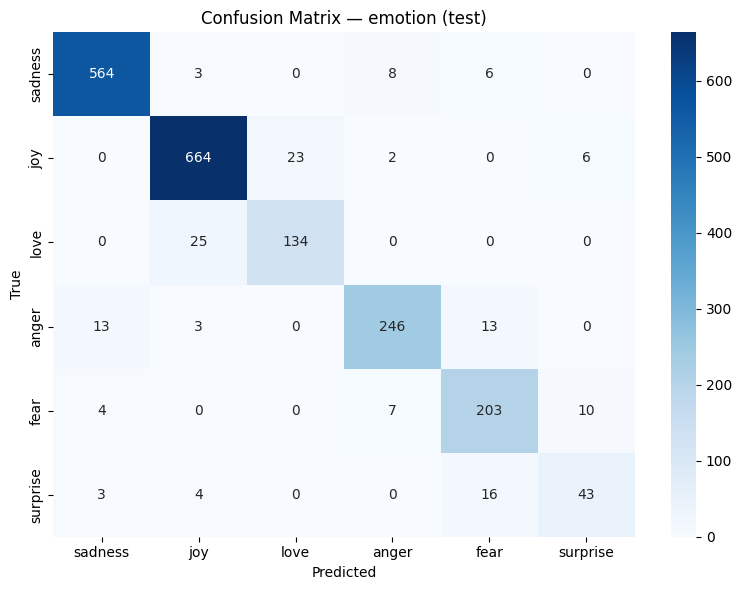

Saved: artifacts/confusion_matrix.png


In [13]:
# Матрица ошибок
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — emotion (test)")
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png", dpi=150)
plt.show()
print("Saved: artifacts/confusion_matrix.png")

In [14]:
# Таблица предсказаний -> artifacts/sample_predictions.csv
test_texts = ds["test"]["text"]
confidences = test_probs.max(axis=1)

df_pred = pd.DataFrame({
    "text": test_texts,
    "true_label": [label_names[l] for l in test_labels],
    "pred_label": [label_names[p] for p in test_preds],
    "confidence": np.round(confidences, 4),
})
df_pred.to_csv("artifacts/sample_predictions.csv", index=False)
print(f"Saved: artifacts/sample_predictions.csv ({len(df_pred)} rows)")
df_pred.head(10)

Saved: artifacts/sample_predictions.csv (2000 rows)


,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambiti...,sadness,sadness,0.9988
1,im updating my blog because i feel shitty,sadness,sadness,0.9991
2,i never make her separate from me because i do...,sadness,sadness,0.9991
3,i left with my bouquet of red and yellow tulip...,joy,joy,0.9994
4,i was feeling a little vain when i did this one,sadness,sadness,0.9988
5,i cant walk into a shop anywhere where i do no...,fear,fear,0.9979
6,i felt anger when at the end of a telephone call,anger,anger,0.9935
7,i explain why i clung to a relationship with a...,joy,joy,0.9510
8,i like to have the same breathless feeling as ...,joy,joy,0.9993
9,i jest i feel grumpy tired and pre menstrual w...,anger,anger,0.9984


## 6. Анализ ошибок

In [15]:
errors = df_pred[df_pred["true_label"] != df_pred["pred_label"]].copy()
print(f"Всего ошибок: {len(errors)} / {len(df_pred)} ({len(errors)/len(df_pred)*100:.1f}%)\n")

print("=== 10 примеров ошибок ===\n")
for _, row in errors.head(10).iterrows():
    print(f"Text: {row['text']}")
    print(f"  True: {row['true_label']}  |  Predicted: {row['pred_label']}  (conf={row['confidence']:.4f})")
    print()

print("=== Самые частые пары путаницы ===")
error_pairs = (
    errors.groupby(["true_label", "pred_label"])
    .size()
    .sort_values(ascending=False)
    .head(5)
)
print(error_pairs)

Всего ошибок: 146 / 2000 (7.3%)

=== 10 примеров ошибок ===

Text: i don t feel particularly agitated
  True: fear  |  Predicted: anger  (conf=0.8145)

Text: i feel if i completely hated things i d exercise my democratic right speak my mind in what ever ways possible and try to enact a change
  True: anger  |  Predicted: sadness  (conf=0.5428)

Text: i feel a bit stressed even though all the things i have going on are fun
  True: anger  |  Predicted: sadness  (conf=0.5702)

Text: i am right handed however i play billiards left handed naturally so me trying to play right handed feels weird
  True: surprise  |  Predicted: fear  (conf=0.5767)

Text: when a friend dropped a frog down my neck
  True: anger  |  Predicted: fear  (conf=0.7944)

Text: i feel my heart is tortured by what i have done
  True: anger  |  Predicted: fear  (conf=0.8867)

Text: i feel agitated with myself that i did not foresee her frustrations earlier leading to the ending of our relationship
  True: fear  |  Predicte

## 7. Выводы

1. **Токенизация:** `bert-base-uncased` использует WordPiece-токенизацию, разбивая редкие слова на подслова (sub-tokens). Special tokens `[CLS]` и `[SEP]` обрамляют каждый вход, `attention_mask` позволяет модели игнорировать padding.

2. **Готовый инференс:** SST-2 модель предсказывает только POSITIVE/NEGATIVE и не различает 6 эмоций — она обучена на другой задаче с другим набором классов. Это подтверждает, что готовая модель без дообучения не подходит для новой целевой задачи.

3. **Fine-tuning:** дообучение `bert-base-uncased` на датасете `emotion` за 3 эпохи значительно улучшает результат — модель корректно различает 6 классов эмоций. Наибольшие трудности — различение близких эмоций (love/joy, anger/sadness, fear/sadness).

4. **Базовый конфиг** для подобной задачи: `bert-base-uncased`, max_length=128, lr=2e-5, 3 эпохи — даёт хорошее соотношение качества и скорости обучения.